# 03 — Feature Engineering and Portfolio Segmentation

In this notebook we move from the cleaned dataset obtained in the previous step to the construction of an analytical dataset suitable for credit risk modelling.

The dataset produced in Notebook 2 already removed variables with excessive missing values, excluded post-origination information to prevent data leakage, and defined the target variable `default_flag`. Therefore, the focus of this stage is no longer data cleaning, but the analytical construction of variables and portfolio understanding.

The main objectives of this notebook are:

- create additional variables with stronger financial interpretation
- transform relevant variables for modelling purposes
- construct basic portfolio segments to analyse borrower and loan characteristics
- study the behaviour of the observed default rate across different segments

This step is typical in real credit risk modelling workflows, where raw variables are transformed into more informative features before estimating Probability of Default models.

At the end of this notebook we obtain a modelling-ready dataset and a modelling configuration file that will be reused directly in the next stage of the project.

In [42]:
# Standard libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
from pathlib import Path
import json

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [43]:
# Define project paths
BASE_PATH = Path("..")
DATA_PATH = BASE_PATH / "data"
PROCESSED_PATH = DATA_PATH / "processed"

INPUT_FILE = PROCESSED_PATH / "lending_club_clean.parquet"
MODEL_DATASET_FILE = PROCESSED_PATH / "lending_club_model_dataset.parquet"
MODEL_CONFIG_FILE = PROCESSED_PATH / "model_features_config.json"

## Load cleaned dataset

We start from the cleaned dataset produced in Notebook 2. This dataset already excludes variables with excessive missing values, removes post-origination information and contains the binary target variable `default_flag`.

In [44]:
# Load dataset
df = pd.read_parquet(INPUT_FILE)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["default_flag"].value_counts(normalize=True))

df.head()

Dataset shape: (581969, 98)

Target distribution:
default_flag
0    0.773727
1    0.226273
Name: proportion, dtype: float64


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,default_flag
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,564.0,560.0,0.0,30.0,1.0,Individual,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,N,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,699.0,695.0,0.0,NaN,1.0,Individual,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,N,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,704.0,700.0,0.0,NaN,1.0,Joint App,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,NaN,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,N,0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,704.0,700.0,0.0,NaN,1.0,Individual,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,N,0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt conso

## Feature engineering

The objective of this section is to transform raw variables into more informative features with clearer economic interpretation.

These transformations are useful not only for predictive modelling, but also for portfolio analysis and risk interpretation.

The Lending Club dataset reports borrower credit quality using a FICO score range (low and high values).  
To obtain a single representative measure of creditworthiness, we compute the midpoint of the range as `fico_mean`.  
This transformation provides a more convenient variable for modelling and facilitates portfolio-level risk analysis based on borrower credit quality.

In [45]:
# Average FICO score
df["fico_mean"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df[["fico_range_low", "fico_range_high", "fico_mean"]].head()

,fico_range_low,fico_range_high,fico_mean
0,675.0,679.0,677.0
1,715.0,719.0,717.0
2,695.0,699.0,697.0
3,695.0,699.0,697.0
4,690.0,694.0,692.0


Annual income tends to be highly skewed, with a small number of borrowers reporting very large values.  
Applying a logarithmic transformation reduces this skewness and stabilizes the scale of the variable.  
This improves the behaviour of statistical models and makes the relationship between income and default risk easier to capture.

In [46]:
# Log transformation of annual income
df["log_annual_inc"] = np.log1p(df["annual_inc"])

df[["annual_inc", "log_annual_inc"]].head()

,annual_inc,log_annual_inc
0,55000.0,10.915107
1,65000.0,11.082158
2,63000.0,11.050906
3,104433.0,11.556311
4,34000.0,10.434145


The loan-to-income ratio measures the size of the loan relative to the borrower’s annual income.  
This variable captures the financial burden implied by the loan and is closely related to repayment capacity.  
Higher values may indicate higher leverage and therefore potentially higher probability of default.

In [47]:
# Loan-to-income ratio
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"]

df[["loan_amnt", "annual_inc", "loan_to_income"]].head()

,loan_amnt,annual_inc,loan_to_income
0,3600.0,55000.0,0.065455
1,24700.0,65000.0,0.380000
2,20000.0,63000.0,0.317460
3,10400.0,104433.0,0.099585
4,11950.0,34000.0,0.351471


The installment-to-income ratio measures the share of the borrower’s annual income required to service the loan payments.  
It approximates the debt service burden associated with the loan by comparing yearly instalments with total income.  
Higher values indicate greater repayment pressure and may therefore be associated with higher default risk.

In [48]:
# Installment-to-income ratio
df["installment_to_income"] = (df["installment"] * 12) / df["annual_inc"]

df[["installment", "annual_inc", "installment_to_income"]].head()

,installment,annual_inc,installment_to_income
0,123.03,55000.0,0.026843
1,820.28,65000.0,0.151436
2,432.66,63000.0,0.082411
3,289.91,104433.0,0.033312
4,405.18,34000.0,0.143005


The original `term` variable is stored as a text field, which is not directly suitable for numerical analysis.  
We therefore extract the number of months and convert it into a numeric variable `term_months`.  
This allows loan maturity to be used more easily in modelling and segmentation analysis.

In [49]:
# Convert term into numeric months
df["term_months"] = df["term"].str.extract(r"(\d+)").astype(int)

df[["term", "term_months"]].head()

,term,term_months
0,36 months,36
1,36 months,36
2,60 months,60
3,60 months,60
4,36 months,36


Credit history length is an important indicator of borrower creditworthiness.  
By comparing the loan origination date (`issue_d`) with the borrower’s earliest recorded credit line (`earliest_cr_line`), we approximate the length of the borrower’s credit history.  
Longer credit histories usually provide more information about borrower behaviour and may be associated with lower credit risk.

In [50]:
# Approximate credit history length in years
df["issue_d_date"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["earliest_cr_line_date"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")

df["credit_history_years"] = (
    (df["issue_d_date"] - df["earliest_cr_line_date"]).dt.days / 365.25
)

df[["issue_d", "earliest_cr_line", "credit_history_years"]].head()

,issue_d,earliest_cr_line,credit_history_years
0,Dec-2015,Aug-2003,12.334018
1,Dec-2015,Dec-1999,16.000000
2,Dec-2015,Aug-2000,15.331964
3,Dec-2015,Jun-1998,17.500342
4,Dec-2015,Oct-1987,28.167009


## Quick check of engineered features

Before moving to segmentation, we inspect a small sample of the engineered variables to verify that the transformations were applied correctly.

In [51]:
engineered_columns = [
    "fico_mean",
    "log_annual_inc",
    "loan_to_income",
    "installment_to_income",
    "term_months",
    "credit_history_years"
]

df[engineered_columns].head()

,fico_mean,log_annual_inc,loan_to_income,installment_to_income,term_months,credit_history_years
0,677.0,10.915107,0.065455,0.026843,36,12.334018
1,717.0,11.082158,0.380000,0.151436,36,16.000000
2,697.0,11.050906,0.317460,0.082411,60,15.331964
3,697.0,11.556311,0.099585,0.033312,60,17.500342
4,692.0,10.434145,0.351471,0.143005,36,28.167009


## Distribution of selected variables

At this stage we only keep a small number of visual checks. The goal is not to produce many charts, but to confirm that the transformed variables behave as expected and to support the interpretation of the feature engineering choices.

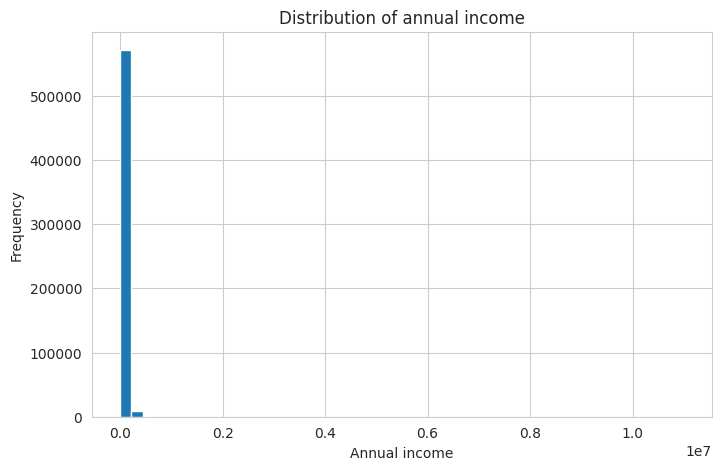

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df["annual_inc"], bins=50)
plt.title("Distribution of annual income")
plt.xlabel("Annual income")
plt.ylabel("Frequency")
plt.show()

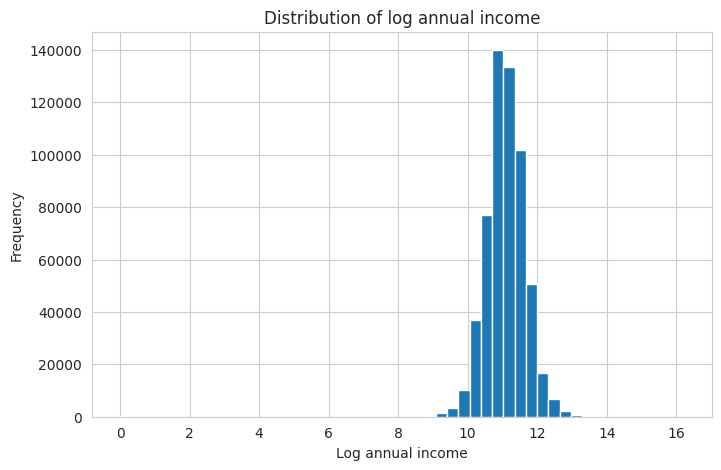

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_annual_inc"], bins=50)
plt.title("Distribution of log annual income")
plt.xlabel("Log annual income")
plt.ylabel("Frequency")
plt.show()

## Portfolio segmentation

After constructing the main analytical variables, the portfolio is segmented into simple and interpretable borrower groups.

These segments allow us to compare observed default behaviour across different parts of the portfolio before moving to predictive modelling.

In [54]:
# Income bands
df["income_band"] = pd.qcut(df["annual_inc"], q=5, duplicates="drop")

# FICO bands
df["fico_band"] = pd.qcut(df["fico_mean"], q=5, duplicates="drop")

# Loan amount bands
df["loan_amnt_band"] = pd.qcut(df["loan_amnt"], q=5, duplicates="drop")

## Default analysis by key portfolio segments

To keep the analysis focused and defendable, we concentrate on a small number of segment-level comparisons that are especially relevant in credit risk modelling:

- credit quality, represented by FICO bands
- loan maturity, represented by `term_months`
- Lending Club internal grade

These views help assess whether the observed default rate behaves in a way that is economically and intuitively consistent.

In [55]:
default_by_fico = (
    df.groupby("fico_band", observed=False)["default_flag"]
    .mean()
    .sort_index()
)

default_by_fico

fico_band
(661.999, 672.0]    0.284024
(672.0, 682.0]      0.263288
(682.0, 697.0]      0.234170
(697.0, 722.0]      0.194083
(722.0, 847.5]      0.128415
Name: default_flag, dtype: float64

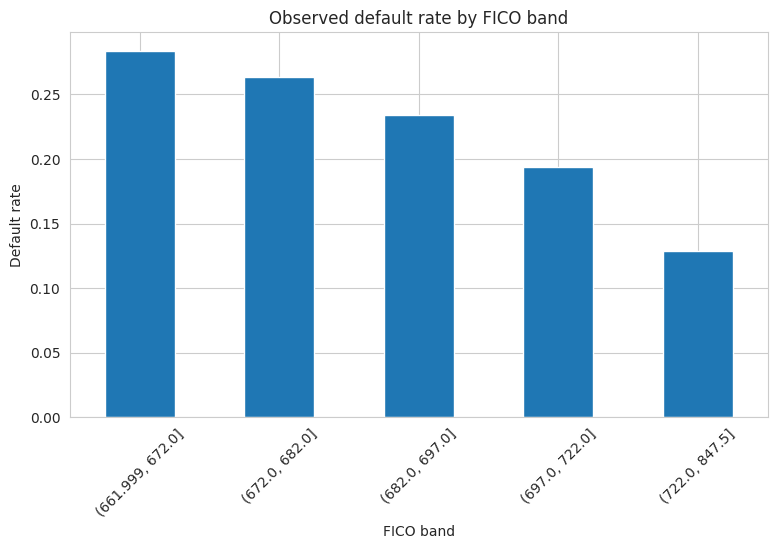

In [56]:
plt.figure(figsize=(9, 5))
default_by_fico.plot(kind="bar")
plt.title("Observed default rate by FICO band")
plt.xlabel("FICO band")
plt.ylabel("Default rate")
plt.xticks(rotation=45)
plt.show()

Higher observed default rates in lower FICO bands would be consistent with the idea that weaker borrower credit quality is associated with higher risk. This is one of the most important checks in the notebook, since it connects the engineered credit quality feature with actual default behaviour.

In [57]:
default_by_term = df.groupby("term_months")["default_flag"].mean()

default_by_term

term_months
36    0.178512
60    0.373652
Name: default_flag, dtype: float64

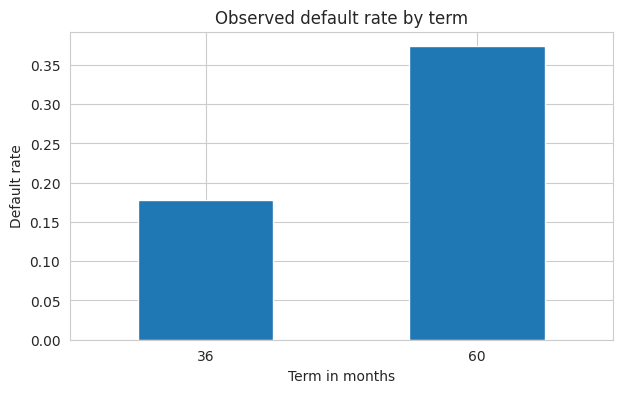

In [58]:
plt.figure(figsize=(7, 4))
default_by_term.plot(kind="bar")
plt.title("Observed default rate by term")
plt.xlabel("Term in months")
plt.ylabel("Default rate")
plt.xticks(rotation=0)
plt.show()

Loan maturity is another relevant risk dimension. Longer-term loans often imply a longer exposure window and may be associated with weaker repayment performance, so comparing default rates by term provides a useful portfolio-level risk view.

In [59]:
grade_order = sorted(df["grade"].dropna().unique())

default_by_grade = (
    df.groupby("grade")["default_flag"]
    .mean()
    .reindex(grade_order)
)

default_by_grade

grade
A    0.067534
B    0.153972
C    0.255564
D    0.350553
E    0.434251
F    0.514873
G    0.552669
Name: default_flag, dtype: float64

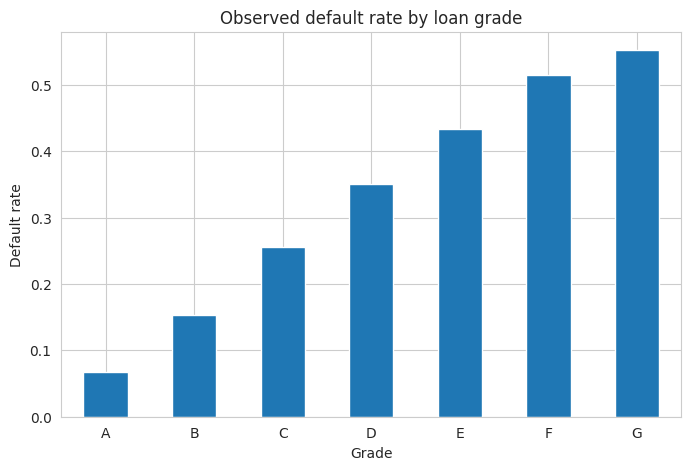

In [60]:
plt.figure(figsize=(8, 5))
default_by_grade.plot(kind="bar")
plt.title("Observed default rate by loan grade")
plt.xlabel("Grade")
plt.ylabel("Default rate")
plt.xticks(rotation=0)
plt.show()

The Lending Club loan grade provides an internal summary of borrower risk. If the observed default rate increases from better grades to weaker grades, this supports the consistency of the portfolio risk structure and strengthens the rationale for the modelling stage.

## Save analytical dataset

The enriched analytical dataset is now exported for the modelling stage. Before saving, interval-based segmentation variables are converted to string format to ensure compatibility with parquet export.

In [61]:
# Convert interval-based segmentation columns to string
band_columns = ["income_band", "fico_band", "loan_amnt_band"]

for col in band_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Save modelling dataset
df.to_parquet(MODEL_DATASET_FILE, index=False)

print("Dataset saved to:", MODEL_DATASET_FILE)

Dataset saved to: ../data/processed/lending_club_model_dataset.parquet


## Modelling variable configuration

To avoid repeating variable selection logic in Notebook 4, we define and save the initial modelling configuration at this stage.

This includes the target variable, excluded columns, engineered features, candidate predictors, and the split between numerical and categorical variables.

In [62]:
# Columns excluded from direct modelling use
excluded_from_model = [
    "default_flag",
    "url",
    "emp_title",
    "title",
    "zip_code",
    "issue_d",
    "issue_d_date",
    "earliest_cr_line",
    "earliest_cr_line_date",
    "pymnt_plan"
]

excluded_from_model = [col for col in excluded_from_model if col in df.columns]

# Engineered features created in this notebook
engineered_features = [
    "fico_mean",
    "log_annual_inc",
    "loan_to_income",
    "installment_to_income",
    "term_months",
    "credit_history_years",
    "income_band",
    "fico_band",
    "loan_amnt_band"
]

engineered_features = [col for col in engineered_features if col in df.columns]

# Candidate predictors
candidate_features = [col for col in df.columns if col not in excluded_from_model]

# Split by type
numerical_features = df[candidate_features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = df[candidate_features].select_dtypes(exclude=["number"]).columns.tolist()

print("Total columns in modelling dataset:", len(df.columns))
print("Excluded columns:", len(excluded_from_model))
print("Engineered features:", len(engineered_features))
print("Candidate predictors:", len(candidate_features))
print("Numerical candidate features:", len(numerical_features))
print("Categorical candidate features:", len(categorical_features))

Total columns in modelling dataset: 109
Excluded columns: 10
Engineered features: 9
Candidate predictors: 99
Numerical candidate features: 84
Categorical candidate features: 15


In [63]:
model_config = {
    "target": "default_flag",
    "excluded_columns": excluded_from_model,
    "engineered_features": engineered_features,
    "candidate_features": candidate_features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features
}

with open(MODEL_CONFIG_FILE, "w") as f:
    json.dump(model_config, f, indent=4)

print("Model configuration saved to:", MODEL_CONFIG_FILE)

Model configuration saved to: ../data/processed/model_features_config.json


## Conclusion

In this notebook the cleaned Lending Club dataset was transformed into an analytical dataset suitable for Probability of Default modelling.

The main contribution of this stage was threefold:

- economically meaningful features were created from raw borrower and loan information
- the portfolio was segmented into simple and interpretable risk groups
- the observed default rate was analysed across key dimensions such as FICO quality, maturity and loan grade

The notebook also produced two reusable outputs for the next stage of the project:

- `data/processed/lending_club_model_dataset.parquet`
- `data/processed/model_features_config.json`

These outputs allow Notebook 4 to begin directly from a modelling-ready dataset and a fixed configuration of candidate variables, without repeating feature engineering or variable definition steps.